In [ ]:
import os, matplotlib.pyplot as plt
 
import numpy as np, xarray as xr
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.basemap import addcyclic

#### **Plot random data snapshot**

(155, 192, 384)


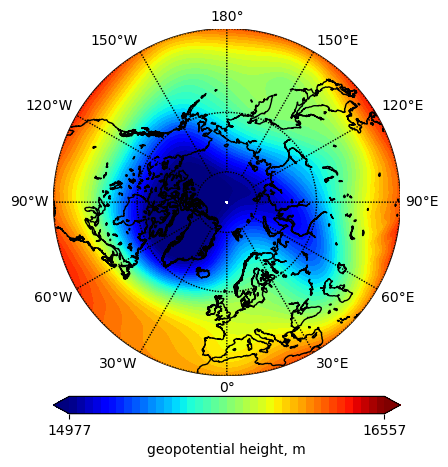

In [21]:
def plot_custom_map(ax,in_data,in_lats,in_lons,good_mask=None,lim1=None,lim2=None,cmap='RdBu_r'):
    if good_mask is None: good_mask=np.logical_not(np.isnan(in_data))
    if len(in_lats.shape)>1:
        in_data,in_lats,in_lons,good_mask=resample_to_regular_grid(in_data,in_lats,in_lons,good_mask)
    
    lats=in_lats
    lons=in_lons#-((in_lons+180)//360)*360
    nroll_lon=0.#-np.argmax(lons)-1
    lons=np.roll(lons,nroll_lon)    
    data=np.ma.masked_array(np.roll(in_data,nroll_lon,axis=-1),mask=np.logical_not(np.roll(good_mask,nroll_lon,axis=-1)))
    
    data,lons=addcyclic(data,lons)
    
    lons,lats=np.meshgrid(lons,lats)
    #lim=np.amax(np.abs(data))/1.5
    lim=[lim1,lim2]
    if lim2 is None: lim[1]=np.nanpercentile(np.ma.filled(data, np.nan),95.)
    if lim1 is None: lim[0]=np.nanpercentile(np.ma.filled(data, np.nan),5.)
    if lim1=='symmetric': 
        if lim2 is None: lim[1]=np.nanpercentile(np.ma.filled(np.ma.abs(data), np.nan),92.)#amax(np.abs(data))/1.5
        lim[0]=-lim[1]
    m = Basemap(projection='nplaea',boundinglat=30,lon_0=0,resolution='l',round=True)
    m.drawcoastlines()
    #m.drawmapboundary(fill_color='0.3')
    im1 = m.contourf(lons,lats,data,cmap=cmap,latlon=True,levels=np.linspace(lim[0],lim[1],41),extend='both')
    m.drawparallels(np.arange(-60.,89.,30.),labels=[0,0,0,0])
    m.drawmeridians(np.arange(0.,360.,30.),labels=[1,1,1,1])
    cb = m.colorbar(im1,"bottom", size="5%", pad="6%",ticks=[lim[0],lim[1]])
    cb.set_label("geopotential height, m")

data_path=os.path.expanduser('~/data/CMIP6.CMIP.MPI-M.MPI-ESM1-2-HR.piControl.r1i1p1f1.day.zg.gn')
ds=xr.open_mfdataset(os.path.join(data_path,'zg_day_MPI-ESM1-2-HR_piControl_r1i1p1f1_gn_22000101-22041231.nc'), decode_times=xr.coding.times.CFDatetimeCoder(use_cftime=True))
ds['zg']=ds['zg'].sel(plev=10000, method='nearest')
ds=ds.drop_vars('plev')
ds=ds.where((ds.time.dt.month == 1),drop=True)
print(ds['zg'].values.shape)

fig=plt.figure(figsize=(5,5))
ax=fig.add_subplot(1,1,1)
plot_custom_map(ax,ds['zg'].values[100,:,:],in_lats=ds['lat'],in_lons=ds['lon'],cmap='jet')
plt.savefig('fig_random_snapshot.png')
plt.show()
ds.close()